In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import poisson
#get path to NEWtags.txt using os module
import os
file_path = os.path.join(os.getcwd(), 'NEWtags.txt')


In [2]:
tags = pd.read_csv(file_path, delimiter = "\\s+",header=None, names=['Channel', 'Time'])
tags.head()

,Channel,Time
0,1,0
1,1,2682
2,1,6604
3,2,9003
4,2,10310


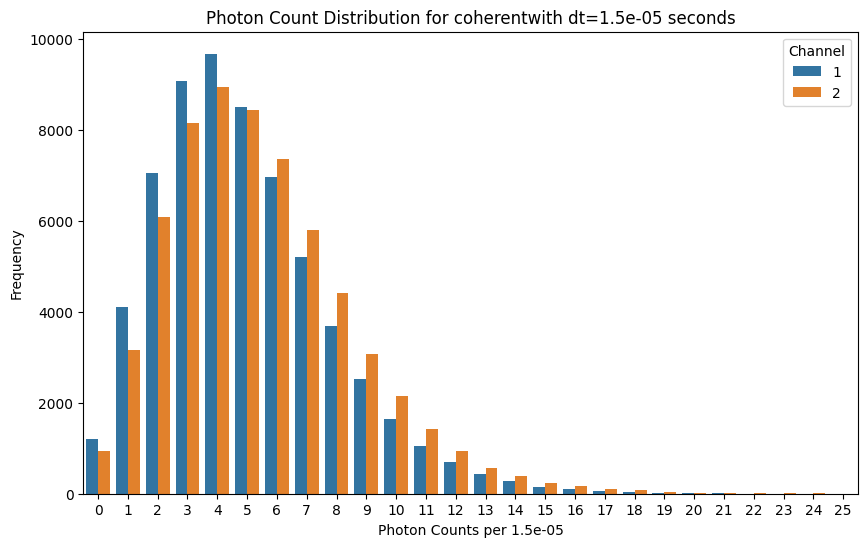

,Channel,Counts,Frequency
36,2,0,946
10,1,0,1211
32,2,1,3156
6,1,1,4117
3,1,2,7047
29,2,2,6093
1,1,3,9090
27,2,3,8164
0,1,4,9681
25,2,4,8940


In [3]:

def photon_count(tags,channel = [1], dt=1e-6, plot = True, fullplot=False, lightsource = 'coherent'):
    '''
    Args: 
        tags: dataframe with detector photon tag files (headers 'Channel' and 'Time')
        channel: list of channels to include in data, e.g. [1,2,3] would include channels 1,2,3 the histogram
        dt: time bin dt in seconds
        fullplot: plot additional histograms for single channels

    Returns:
        Bar plot of photon count distribution for specified channels and dt
    '''
    #convert timestamp to seconds and add a column for time bins
    localtags = tags.copy()
    localtags['Time'] = localtags['Time']*156.25e-12
    localtags['dt'] = localtags['Time']//dt
    #agregate events per channel and time bin
    localtags_grouped = localtags.groupby(['Channel','dt']).size().reset_index(name='Counts')
    localtags_grouped.sort_values(by='dt')
    #reindex to add missing time bins with 0 counts
    all_dt = pd.DataFrame({'dt': np.arange(0, localtags_grouped['dt'].max()+1)})
    all_channels = pd.DataFrame({'Channel': channel})
    all_combinations = all_channels.merge(all_dt, how='cross')
    localtags_grouped = all_combinations.merge(localtags_grouped, on=['Channel','dt'], how='left').fillna(0)
   
    #frequencies of counts by channel
    localtags_freq = localtags_grouped.groupby('Channel')['Counts'].value_counts().reset_index(name='Frequency')

    #frequency histogram of counts by 
    localtags_freq = localtags_freq.sort_values(by='Counts')
    
    localtags_freq = localtags_freq[localtags_freq['Channel'].isin(channel)]
    #data type conversion for plotting
    localtags_freq['Counts'] = localtags_freq['Counts'].astype(int)
    localtags_freq['Frequency'] = localtags_freq['Frequency'].astype(int)
    localtags_freq['Channel'] = localtags_freq['Channel'].astype('category')

    #plotting

    if plot:
        plt.figure(figsize=(10,6))
        sns.barplot(data=localtags_freq, x='Counts', y='Frequency', hue='Channel', dodge=True)
        plt.xlabel(f'Photon Counts per {dt}')
        plt.ylabel('Frequency')
        plt.title(f'Photon Count Distribution for {lightsource}with dt={dt} seconds')
        plt.show()

    if fullplot and plot and len(channel) > 1: 
        #additional plots for single channels
        for ch in channel:
                plt.figure(figsize=(10,6))
                sns.barplot(data=localtags_freq[localtags_freq['Channel']==ch], x='Counts', y='Frequency',color=sns.color_palette()[ch-1])
                plt.xlabel(f'Photon Counts per {dt}')
                plt.ylabel('Frequency')
                plt.title(f'Photon Count Distribution for Channel {ch} with dt={dt} seconds')
                plt.show()
    return localtags_freq

photon_count(tags, channel=[1,2], dt=15e-6)
    
    

### Experiment 1 Notes
Walked the beam, peak power was around 0.637µV+-idk. 
detector downtime measured to be 43.387+-0.065ns. cursor precision was 0.092ns. Insert screenshot
Rise time 5.669+-0.065ns


dark events for 1,2 and 5 second integration




In [4]:
noise1 = [420,450,400,457,416,465,398,418,415,434,401,415,429,469,454,409,453,432,456,450,426,441,439,444,424,444,458,408,451,457,440,476,442,441,448,434,431,464,427,479,482,422,451,425,433,423,442,467,418,436,404,441,444,457,464,439,412,431,490,430,422,427, 417,428,400,416,433,425,449,445,428,420]
noise2 = [845,843,814,846,831,852,855,834,863,856,853,854,803,872,844,820,850,824,886,826,836,832,809,846,851,823,819,846,897,925,890,855,843,883,843,857,878,884,852,907,849,872,819,840,876,849,860,908,861,826,829,887,826,881,841,821,860,857,904,800,839,873,833,920,912,849,823,851,848,895,906,861, 845,832,871,889, 792, 874, 902, 897]
noise5 = [2181,2142,2224,2202,2158,2181,2199,2192,2209,2159,2141,2235,2181,2226,2325,2222,2256,2217,2186,2231,2218,2243,2281,2277,2185,2222,2231, 2278, 2284, 2145, 2118,2171,2187,2225, 2256,2192,2202,2120,2267,2157,2173,2188,2200,2299,2249,2162, 2277,2165,2174, 2165, 2181,2261,2258,2158,2169, 2223, 2246,2241, 2240, 2273, 2186, 2299, 2143]
print(len(noise5))
print(np.mean(noise5))
print(np.std(noise5))

63
2210.4126984126983
47.62706810762229


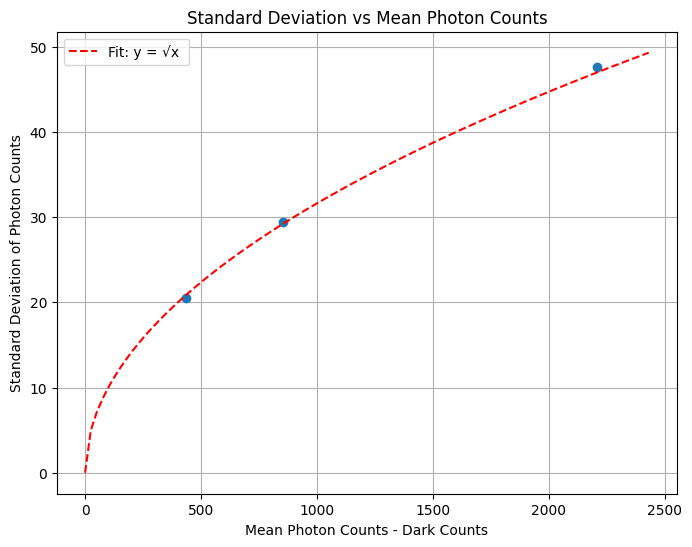

In [5]:
#sqrt mean vs std dev for all in a data list
x = [np.mean(noise1),np.mean(noise2), np.mean(noise5)]
y = [np.std(noise1), np.std(noise2), np.std(noise5)]
plt.figure(figsize=(8,6))
plt.plot(x,y,'o')
plt.xlabel('Mean Photon Counts - Dark Counts')
plt.ylabel('Standard Deviation of Photon Counts')
plt.title('Standard Deviation vs Mean Photon Counts')
plt.grid()
#fit a square root function to the data
from scipy.optimize import curve_fit

def sqrt_func(x):
    return np.sqrt(x)
xmodel = np.linspace(0, max(x)*1.1, 100)
ymodel = sqrt_func(xmodel)

plt.plot(xmodel, ymodel, 'r--', label=f'Fit: y = √x ')
plt.legend()
plt.show()





### Laser On notes

Rotating plate frequency is 100+-0.5Hz

In [6]:
#lnoise1 = [23166, 22709, 23092, 23131, 22649, 23130, 23095, 23052, 23005, 22810, 23189, 23050, 22871, 23300, 22941, 23010, 22653, 22982, 23003, 23560, 23063, 23061, 23037, 23318, 23064, 23307, 22801, 23199, 23326, 22901, 23163, 23472, 22943, 22880, 22871, 22808, 23016, 22972, 23156, 23092, 22940, 22934, 23097, 23069, 22923, 22927, 23130, 23212, 23049, 23038, 23149, 22775, 23158, 22894, 23171, 23041, 22863, 23043, 23418, 23161, 23149, 23048, 23215, 23021, 23016, 23018, 23058, 23083, 23069, 23222, 23140, 23008, 23107, 23078, 23110, 23119, 23129, 23038, 23065, 22997, 23095, 23041, 22992, 23000, 22942, 23020, 23018, 23079, 23036, 23105, 23045, 23033, 23011]
lnoise21 = [45655,45777, 45987, 46066, 45621, 45549, 45833, 45599, 45739, 45525, 45681, 45673, 45565, 45460, 45620, 45077, 45288, 45708, 45313, 45274, 45477, 45632, 45457, 45272, 45607,45835, 45860, 45868, 45784, 45759, 45517, 45801, 46065, 45768, 45579, 45600, 45549, 45579, 45579, 45857, 46386, 45672, 45774, 46011, 45749, 45760, 46142, 45621, 45535, 45695, 45878, 45815, 45819, 45913, 45899, 45472, 45706, 45710, 45778, 45757, 45777, 45836, 45427, 45670, 45849, 45438, 45471, 45982, 45821, 45887, 45386, 45991, 45772, 45622, 45865, 45895, 45959, 45936, 45780, 45789, 45781, 45697]
lnoise22 = [83299, 83423, 83416, 82528, 83470, 82943, 83149, 83615, 83343, 83424, 83299, 83290, 83200, 83519, 83482, 83564, 83366, 83404, 83367, 82927, 83507, 83457, 83393, 83421, 83445, 83267, 83616, 83174, 83072, 83578, 83411, 83555, 83077, 82822, 83115, 83295, 82344, 83533, 82515, 84078, 82935, 83241, 83185, 83291, 83294, 83310, 83198, 83243, 83209, 82909, 82881, 82921, 83130, 82700,83036,83013, 82929, 83438, 82929, 83318, 83345, 83085, 83426, 83585, 83523, 83125, 83319, 83040, 82940]
lnoise23 = [149617, 149632, 150095, 150422, 150779, 149854, 149451, 150295, 149476, 149594, 149680, 150503, 150038, 150068, 149800, 149808, 150107, 150355, 150283, 150283, 150262,149625, 150716, 150157, 149560, 149930, 149575, 149922, 149221, 149911, 149361, 150009, 150191, 149643, 149877, 148742, 149939, 150023, 149727, 149830, 149732, 149991, 149636, 150286, 149846, 150287, 149768, 150340, 150400, 150164, 150337, 150602, 150400]
print(len(lnoise23))
print(np.mean(lnoise23).round(3))
print(np.std(lnoise23).round(3))
#lnoise5 = [114499, 114209, 113993, 113342, 114150, 114767, 113962, 113880, 114155, 114901, 114134, 114499, 113687, 114418, 113981, 114401, 114395, 114393, 114141, 113498, 114030, 113486, 114094, 114522, 113962, 113467, 113678, 114207, 113521, 114259, 114057, 113683, 114260, 113879, 113396, 113526,113917, 114163, 113645, 114317,113773, 114074, 113848, 113728, 113301, 113827, 113911, 113919, 114055, 114373, 113906, 114169, 114042, 113666, 114006, 113811, 113742, 114169, 114075, 114197, 114235, 114244]



53
149965.094
388.647


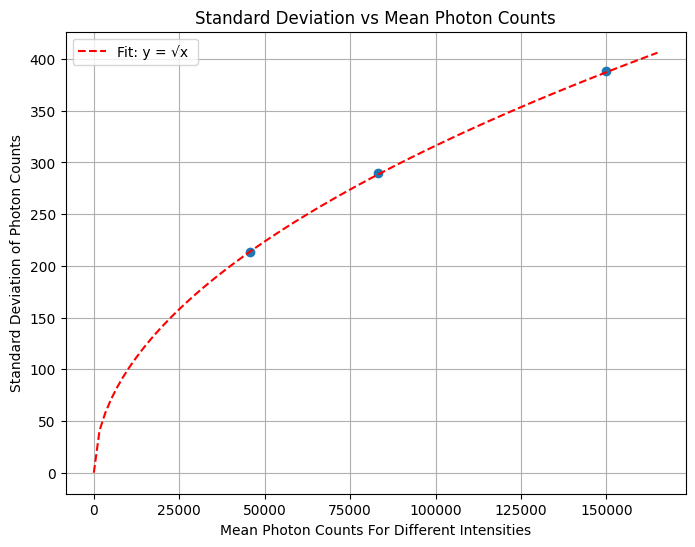

In [7]:
#sqrt mean vs std dev for all in a data list
x = [np.mean(lnoise21),np.mean(lnoise22), np.mean(lnoise23)]
y = [np.std(lnoise21), np.std(lnoise22), np.std(lnoise23)]
plt.figure(figsize=(8,6))
plt.plot(x,y,'o')
plt.xlabel('Mean Photon Counts For Different Intensities')
plt.ylabel('Standard Deviation of Photon Counts')
plt.title('Standard Deviation vs Mean Photon Counts')
plt.grid()
#fit a square root function to the data
from scipy.optimize import curve_fit

def sqrt_func(x):
    return np.sqrt(x)
xmodel = np.linspace(0, max(x)*1.1, 100)
ymodel = sqrt_func(xmodel)
plt.plot(xmodel, ymodel, 'r--', label=f'Fit: y = √x ')

plt.legend()
plt.show()



# Experiment 3

full coincidence:
channel 1 delay = 2.96ns+-0.0775ns
channel 2 delay = 0ns+-0.0775ns

half coincidence 1:
channel 1 delay = 6.08ns
channel 2 delay = 0

half coincidence 2: 
channel 1 delay = 0
channel 2 delay = 0


coic. window in GUI = 2.96875



In [8]:
np.sqrt(2)*0.0775

np.float64(0.10960155108391487)

In [9]:
def g2(T, Nc, N1, N2, W):
    #uncertainty calculation for g2
    sd1 = np.sqrt(N1)
    sd2 = np.sqrt(N2)
    sdNc = np.sqrt(Nc)
    sdW = 0.0775e-9
    N = (T*Nc)/(W*N1*N2)
    dN_dNc = T/(W*N1*N2)
    dN_dN1 = - (T*Nc)/(W*N1**2*N2)
    dN_dN2 = - (T*Nc)/(W*N1*N2**2)
    dN_dW = - (T*Nc)/(W**2*N1*N2)
    sdN = np.sqrt((dN_dNc*sdNc)**2 + (dN_dN1*sd1)**2 + (dN_dN2*sd2)**2 + (dN_dW*sdW)**2)
    print(f'g2 uncertainty: {sdN}')
    return (T*Nc)/(W*N1*N2)

def g2single(Nt, N1t, N2t, N12t):
    #g2 single photon uncertainty calculation
    sdNt = np.sqrt(Nt)
    sdN1t = np.sqrt(N1t)
    sdN2t = np.sqrt(N2t)
    sdN12t = np.sqrt(N12t)
    N = (Nt*N12t)/(N1t*N2t)
    dN_dNt = N12t/(N1t*N2t)
    dN_dN1t = - (Nt*N12t)/(N1t**2*N2t)
    dN_dN2t = - (Nt*N12t)/(N1t*N2t**2)
    dN_dN12t = Nt/(N1t*N2t)
    sdN = np.sqrt((dN_dNt*sdNt)**2 + (dN_dN1t*sdN1t)**2 + (dN_dN2t*sdN2t)**2 + (dN_dN12t*sdN12t)**2)
    print(f'g2 single photon uncertainty: {sdN}')
    return (Nt*N12t)/(N1t*N2t)

#coherent light numbers
print(g2(300, 19555, 30492053, 31259926, 6.08e-9))

#pseudothermal light, 139Hz+-0.5Hz
print(g2(300, 9085, 16788276, 17369038, 6.08e-9))

g2 uncertainty: 0.014797354304014004
1.0122805308537899
g2 uncertainty: 0.02538500667989242
1.5373074836926732


tag files 2s integration period both

In [48]:
print(g2(300,20999,20440407, 25658522,6.08e-9 ))
print(g2single(61734854, 2584187, 2846868, 2127))


g2 uncertainty: 0.028641707682462488
1.9755822420218934
g2 single photon uncertainty: 0.0003873210257291933
0.017848702347043065


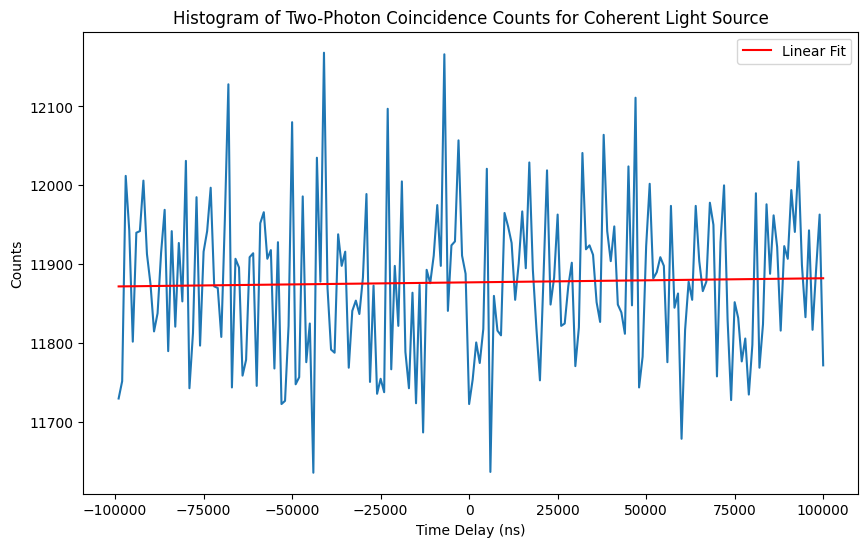

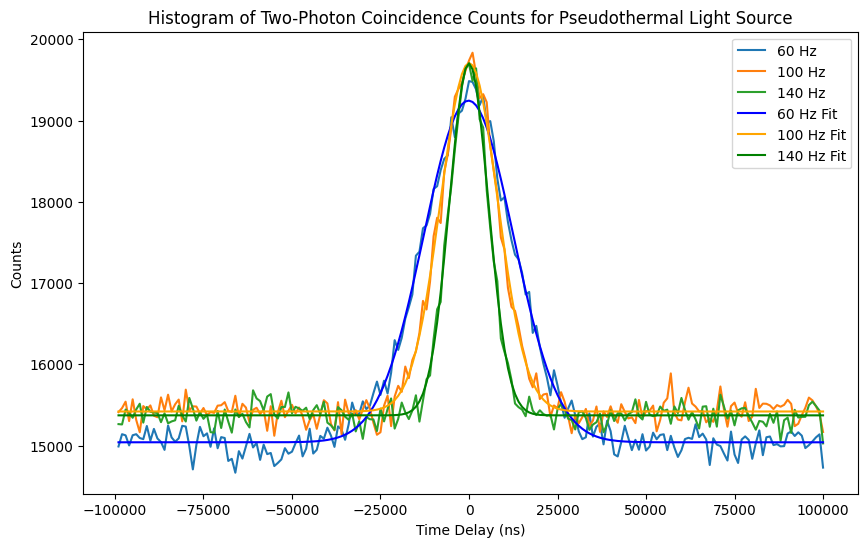

In [76]:
#historgam plots for coherent light and pseudothermal light  headers starts on row 10
coherent = pd.read_csv('JC_coherent.txt', delimiter = "\\s+", header = 9)
pseudothermal60 = pd.read_csv('JC_pseudothermal60.txt', delimiter = "\\s+", header = 9)
pseudothermal100 = pd.read_csv('JC_pseudothermal100.txt', delimiter = "\\s+", header = 9)
pseudothermal140 = pd.read_csv('JC_pseudothermal140.txt', delimiter = "\\s+", header = 9)
#truncate first 10 data points in time seires
coherent = coherent[coherent['tAB'] > -100000]
pseudothermal60 = pseudothermal60[pseudothermal60['tAB']>-100000]
pseudothermal100 = pseudothermal100[pseudothermal100['tAB']>-100000]
pseudothermal140 = pseudothermal140[pseudothermal140['tAB']>-100000]

#fit linear model to coherent data

def linear(x, m, b):
    return m * x + b

fit_linear_params, covariance = curve_fit(linear, coherent['tAB'], coherent['nAB'], p0=[0, np.mean(coherent['nAB'])])




#fit linear model to coherent data

plt.figure(figsize=(10,6))
sns.lineplot(data=coherent, x='tAB', y='nAB')
#fit
sns.lineplot(x=coherent['tAB'], y=linear(coherent['tAB'], *fit_linear_params), color='red', label='Linear Fit')
plt.xlabel('Time Delay (ns)')
plt.ylabel('Counts')
plt.title('Histogram of Two-Photon Coincidence Counts for Coherent Light Source')
plt.show()


#fit gaussian to pseudothemal data
def gaussian(x, amplitude, mean, stddev, baseline):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2)) + baseline


fi60t_params, covariance = curve_fit(gaussian, pseudothermal60['tAB'], pseudothermal60['nAB'], p0=[max(pseudothermal60['nAB']), 0, 10000, min(pseudothermal60['nAB'])])
fi100t_params, covariance = curve_fit(gaussian, pseudothermal100['tAB'], pseudothermal100['nAB'], p0=[max(pseudothermal100['nAB']), 0, 10000, min(pseudothermal100['nAB'])])
fi140t_params, covariance = curve_fit(gaussian, pseudothermal140['tAB'], pseudothermal140['nAB'], p0=[max(pseudothermal140['nAB']), 0, 10000, min(pseudothermal140['nAB'])])   


#plot barplot of pseudothermal light counts
plt.figure(figsize=(10,6))
sns.lineplot(data=pseudothermal60, x='tAB', y='nAB', label='60 Hz')
sns.lineplot(data=pseudothermal100, x='tAB', y='nAB', label='100 Hz')
sns.lineplot(data=pseudothermal140, x='tAB', y='nAB', label='140 Hz')
#fits
sns.lineplot(x=pseudothermal60['tAB'], y=gaussian(pseudothermal60['tAB'], *fi60t_params), color='blue', label=f'60 Hz Fit')
sns.lineplot(x=pseudothermal100['tAB'], y=gaussian(pseudothermal100['tAB'], *fi100t_params), color='orange', label='100 Hz Fit')
sns.lineplot(x=pseudothermal140['tAB'], y=gaussian(pseudothermal140['tAB'], *fi140t_params), color='green', label='140 Hz Fit')
plt.xlabel('Time Delay (ns)')
plt.ylabel('Counts')
plt.title('Histogram of Two-Photon Coincidence Counts for Pseudothermal Light Source')
plt.show()

[ 2.59476754e+03 -1.26602857e+01  1.88127269e-01  3.86156839e+00]


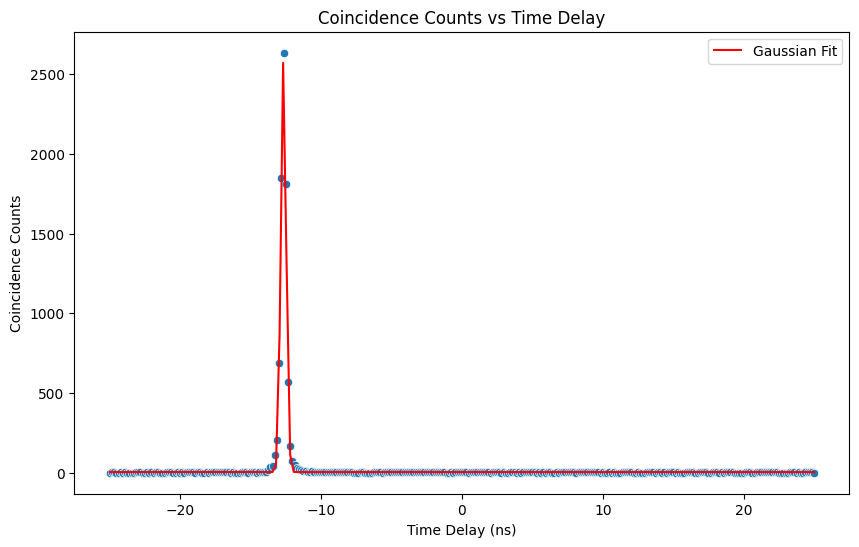

In [12]:
from scipy.optimize import curve_fit
def gaussian(x, amplitude, mean, stddev, baseline):
    return baseline + amplitude * np.exp(-((x - mean) / (np.sqrt(2) * stddev))**2)


counts = pd.read_csv('counts.txt', delimiter = "\\s+", header = 9)

popt, pcov = curve_fit(gaussian, xdata= counts['tAB'], ydata=counts['nAB'], p0 = [2500, -12, 3,0])

print(popt)


#plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=counts, x='tAB', y='nAB')
x_fit = np.linspace(counts['tAB'].min(), counts['tAB'].max(), 200)
plt.plot(x_fit, gaussian(x_fit, *popt), color = 'r', label='Gaussian Fit')
plt.xlabel('Time Delay (ns)')
plt.ylabel('Coincidence Counts')
plt.title('Coincidence Counts vs Time Delay')
plt.legend()
plt.show()

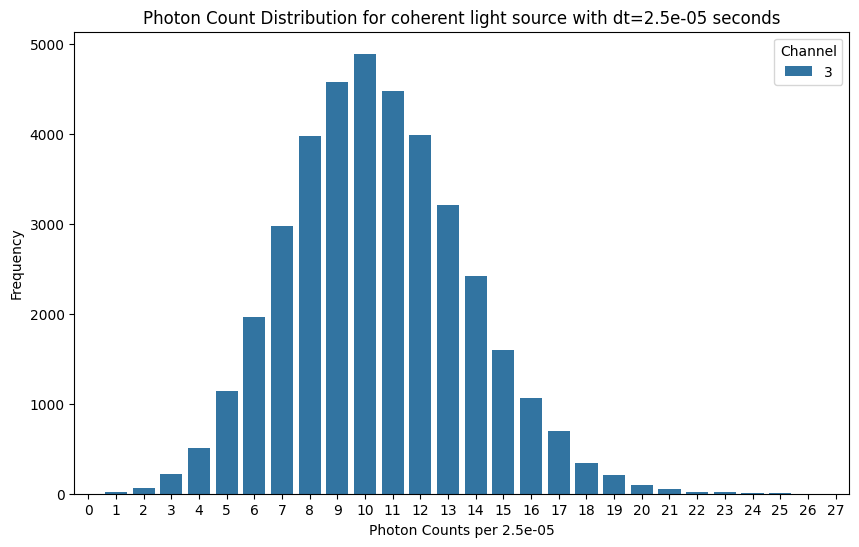

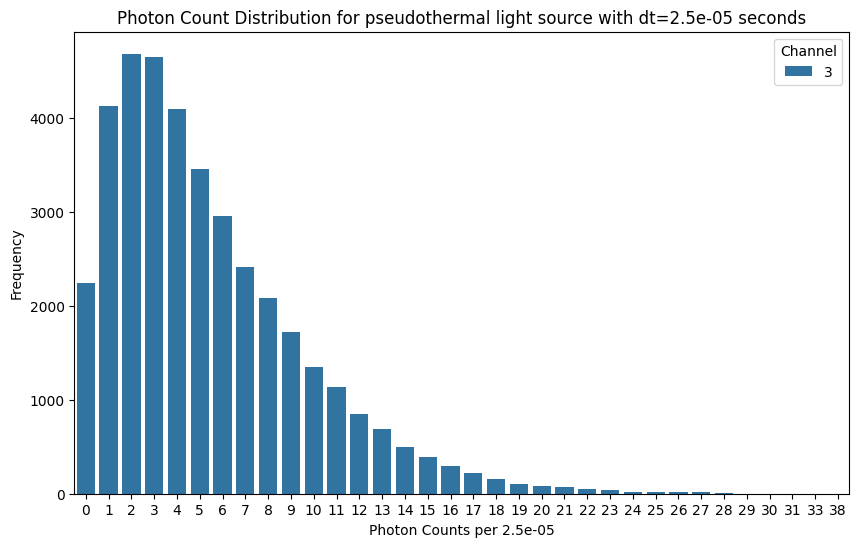

,Channel,Counts,Frequency
7,3,0,2246
2,3,1,4131
0,3,2,4689
1,3,3,4653
3,3,4,4096
4,3,5,3458
5,3,6,2964
6,3,7,2414
8,3,8,2091
9,3,9,1721


In [16]:
lasertags = pd.read_csv('laserTAGS.txt', delimiter = "\\s+",header=None, names=['Channel', 'Time'])
pseudothermaltags = pd.read_csv('pseudothermalTAGS.txt', delimiter = "\\s+",header=None, names=['Channel', 'Time'])

photon_count(lasertags, channel=[3], dt=25e-6, lightsource= "coherent light source ")
photon_count(pseudothermaltags, channel=[3], dt=25e-6, lightsource='pseudothermal light source ')

# Convolved Distributions
Basically we're trying to find the best fit function to fit to our distributions. We do this by finding the convolution between poisson and thermal distribution and then fitting this convolution to our data.  

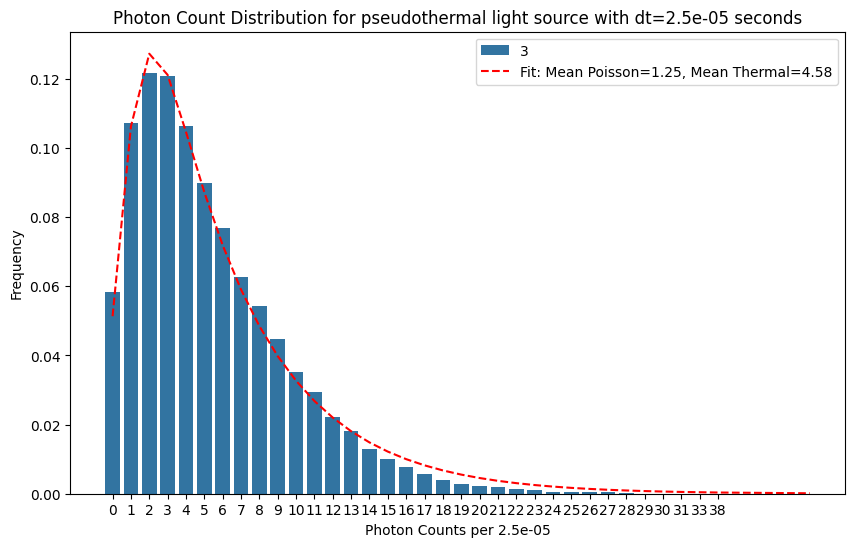

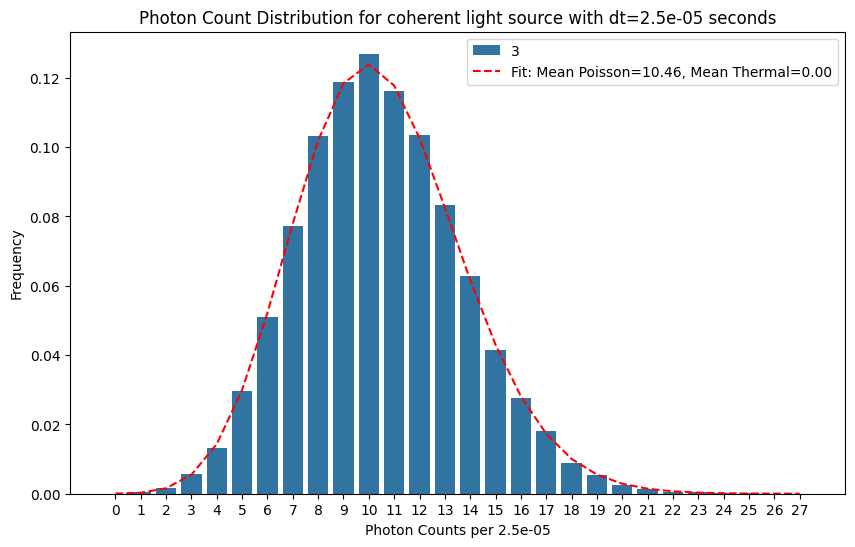

In [77]:
import scipy.stats as stats
import scipy as sp
import math
def poisson(x, mean):
    return stats.poisson.pmf(x, mean)

def thermal(x, mean):
    return  (1/(mean + 1)) * (mean/(mean + 1))**x   
#plot poisson distribution with mean 5

def con_x(x, mean_p, mean_t):
    #convolution of poisson and thermal distributions at point x
    conv = 0
    for k in range(0, int(x)+1):
        conv += poisson(k, mean_p) * thermal(x - k, mean_t)
    return conv

def convolve_distributions(x, mean_p, mean_t):
    y = [con_x(i, mean_p, mean_t) for i in x]
    return y

#subroutine to fit to data
def fit_convolution(xdata, ydata, mean_p_init, mean_t_init):
    def convolve_fit(x, mean_p, mean_t):
        return [con_x(i, mean_p, mean_t) for i in x]
    popt, pcov = curve_fit(convolve_fit, xdata, ydata, p0=[mean_p_init, mean_t_init])
    return popt

def plot_fit(tags, channel, dt, mean_p_init, mean_t_init, lightsource):
    localtags_freq = photon_count(tags, channel=channel, dt=dt, plot=False)
    localtags_freq['Frequency'] = localtags_freq['Frequency']/localtags_freq['Frequency'].sum()
    xdata = localtags_freq['Counts'].values
    ydata = localtags_freq['Frequency'].values
    popt = fit_convolution(xdata, ydata, mean_p_init, mean_t_init)
    xmodel = xdata
    ymodel = convolve_distributions(xmodel, popt[0], popt[1])
    plt.figure(figsize=(10,6))
    sns.barplot(data=localtags_freq, x='Counts', y='Frequency', hue='Channel', dodge=True)
    plt.plot(xmodel, ymodel, 'r--', label=f'Fit: Mean Poisson={popt[0]:.2f}, Mean Thermal={popt[1]:.2f}')
    plt.xlabel(f'Photon Counts per {dt}')
    plt.ylabel('Frequency')
    plt.title(f'Photon Count Distribution for {lightsource}with dt={dt} seconds')
    plt.legend()
    plt.show()

plot_fit(pseudothermaltags, channel=[3], dt=25e-6, mean_p_init=1, mean_t_init=1, lightsource='pseudothermal light source ')
plot_fit(lasertags, channel=[3], dt=25e-6, mean_p_init=12, mean_t_init=1, lightsource= "coherent light source ")